## AACR 2025 会议 presentation 信息下载

URL: https://www.abstractsonline.com/pp8/#!/20273

**每年数据链接只有 URL 中最末尾数值会发生变化**

1. 会议内容组织方式为 session > presentation
2. 首先根据日程、或关注session 获取全部 presentation id，然后逐个id抓取对应内容
3. 其中 session 或会议日常没有规律，需要手动在网页端开发者模式中获取全部 json url 路径

In [1]:
import os 

os.listdir(".")

['session', '.ipynb_checkpoints', 'AACR-2025.ipynb']

## get all presentation id

- AACR 网站需要根据 backpack 信息验证真实用户
- backpack 信息获取来源为开发者模式 -> 网络 -> Headers
  > backpack 有效期约1天, 长时间运行需要关注是否过期

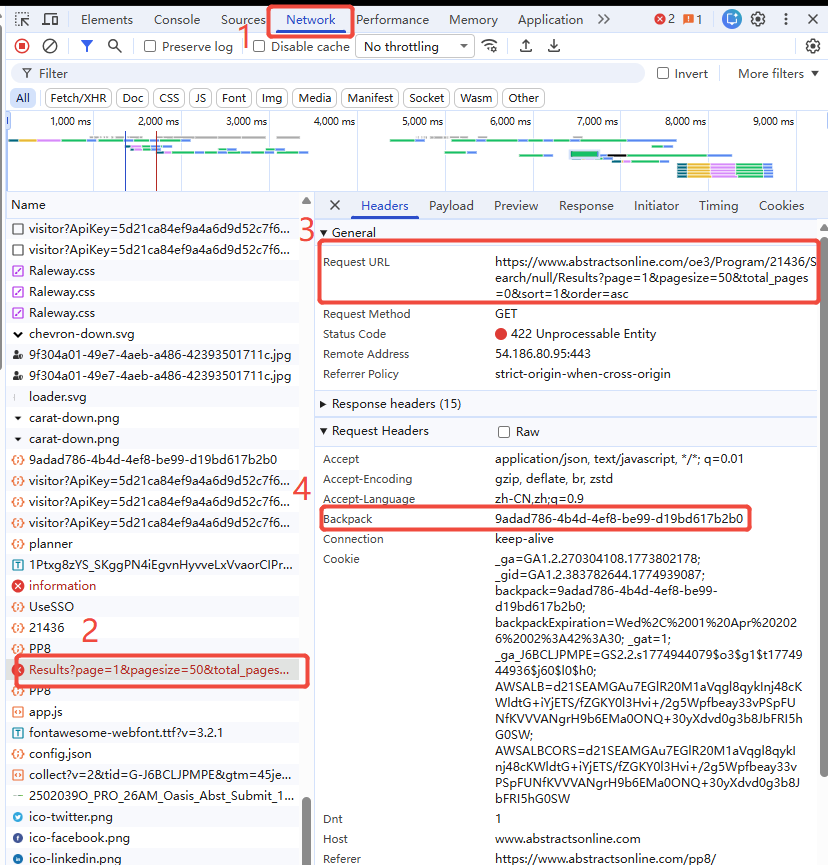

In [2]:
import json
import requests
from os.path import exists

def get_aacr_by_url(url, cahcefile=None):

    header = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36",
        # "cookie": "_ga=GA1.2.1393456963.1736303654; _ga_DR4SQFLWZ1=GS1.1.1739248782.3.0.1739248826.16.0.0; backpack=d886cb72-cb6b-4e95-8012-309f30af6108; backpackExpiration=Tue%2C%2013%20May%202025%2022%3A42%3A13; _gid=GA1.2.345013580.1747104134; _gat=1; _ga_J6BCLJPMPE=GS2.2.s1747104134$o39$g1$t1747104158$j36$l0$h0; AWSALB=hEXVwQlSTgv67pYxfkYWsg2vweytb479r2PgwLu1GHEYlm9a2M7SlMGTTX3zMNRbhXTe2YT0m04F9jDY2ap48b7JEcQqDmvREGz5taozx9YGdPLWN+mFoMr1lmYI; AWSALBCORS=hEXVwQlSTgv67pYxfkYWsg2vweytb479r2PgwLu1GHEYlm9a2M7SlMGTTX3zMNRbhXTe2YT0m04F9jDY2ap48b7JEcQqDmvREGz5taozx9YGdPLWN+mFoMr1lmYI",
        "backpack": "04cb84bd-064f-4427-9e0d-5c765d357e71",
        "content-type": "application/json",
        "accept": "application/json",
    }

    if (cahcefile is not None) and exists(cahcefile) and os.path.getsize(cahcefile) > 0: 
        with open(cahcefile) as fi: 
            content = json.load(fi)
            return content 
    
    res = requests.get(url, headers=header)
    content = res.json()
    if (cahcefile is not None): 
        with open(cahcefile, "w") as fi: 
            json.dump(content, fi, indent=2)

    return content

> 展示url通过 AACR2026 会议日常获取，不同日程对应 url 没有规律，需要浏览器手动获取

In [3]:
aacr_annual_id = 20273

### for loop

**注意这里需要在页面上选择 presentation**

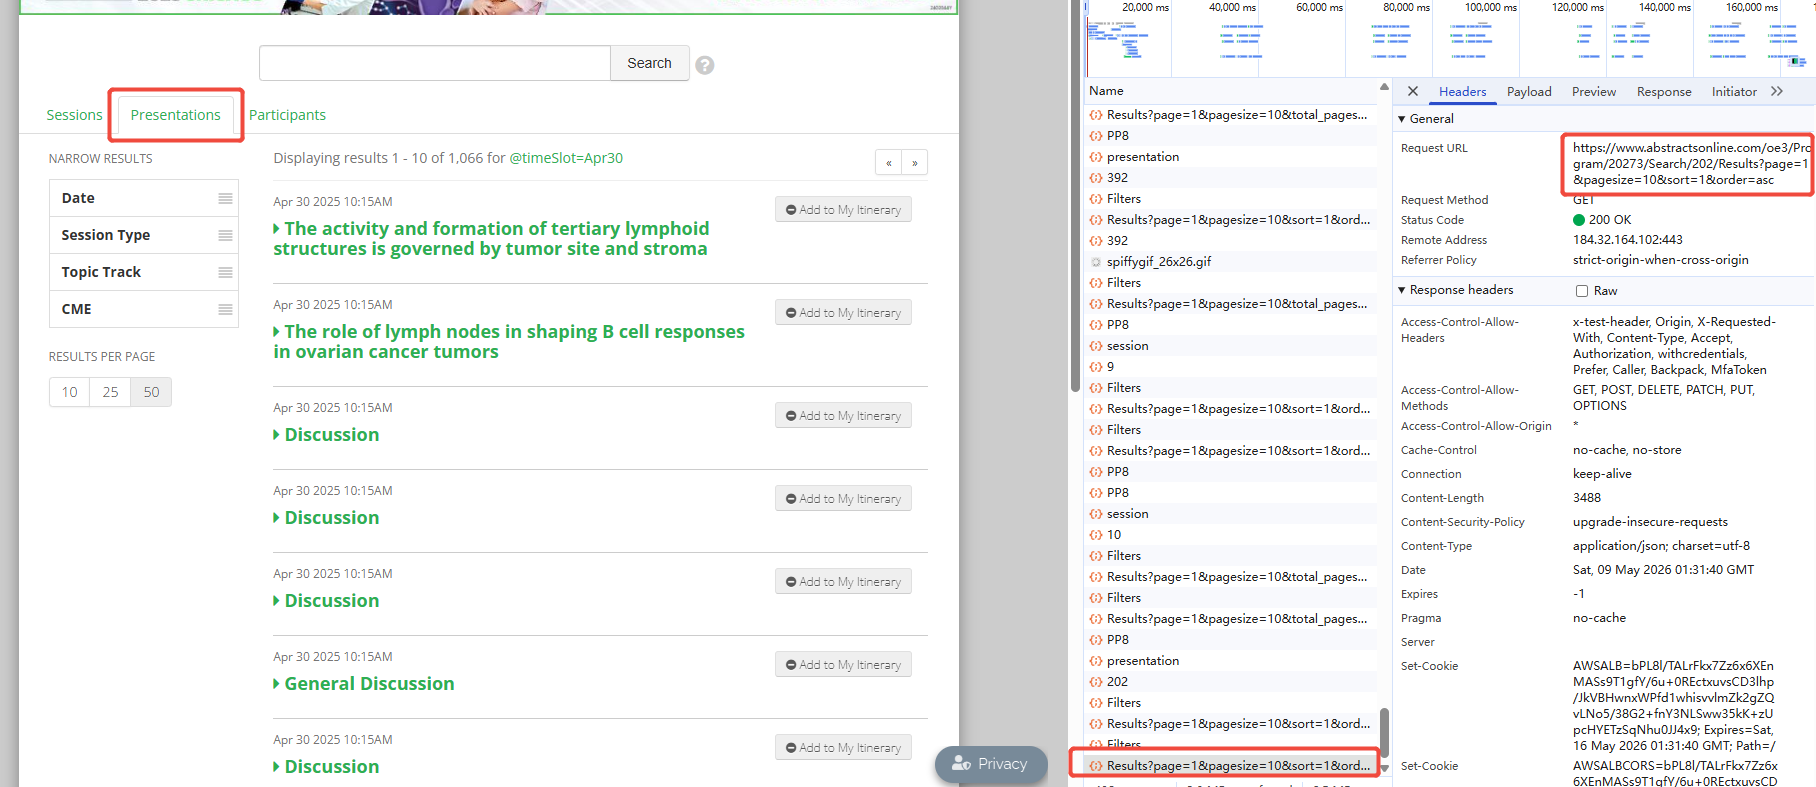

In [4]:
from math import ceil
from os import makedirs

if not exists("schedule"):
    makedirs("schedule")


URLS = {
    "apr25": "https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Search/77/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr26": "https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Search/375/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr27": "https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Search/390/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr28": "https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Search/391/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr29": "https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Search/392/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr30": "https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Search/202/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
}

for x, y in URLS.items(): 
    page = 1
    url = y.format(page=page, suffix="", aacr_annual_id=aacr_annual_id) 
    res = get_aacr_by_url(url, f"schedule/ids_{x}_{page}.json")
    total = int(res["Search"]["Count"])
    count = len(res["Results"])
    print(x, page, count, total, url)

    # "https://www.abstractsonline.com/oe3/Program/21436/Search/30/Results?page=3&pagesize=10&total_pages=47&total_entries=468&sort=1&order=asc"
    pages = ceil(total / 50)
    suffix = f"&total_pages={pages}&total_entries={total}"
    while count < total:
        page += 1
        url = y.format(page=page, suffix=suffix, aacr_annual_id=aacr_annual_id)
        res = get_aacr_by_url(url, f"schedule/ids_{x}_{page}.json")
        count += len(res["Results"])
        print(x, page, count, total, url)


apr25 1 50 145 https://www.abstractsonline.com/oe3/Program/20273/Search/77/Results?page=1&pagesize=50&sort=1&order=asc
apr25 2 100 145 https://www.abstractsonline.com/oe3/Program/20273/Search/77/Results?page=2&total_pages=3&total_entries=145&pagesize=50&sort=1&order=asc
apr25 3 145 145 https://www.abstractsonline.com/oe3/Program/20273/Search/77/Results?page=3&total_pages=3&total_entries=145&pagesize=50&sort=1&order=asc
apr26 1 50 468 https://www.abstractsonline.com/oe3/Program/20273/Search/375/Results?page=1&pagesize=50&sort=1&order=asc
apr26 2 100 468 https://www.abstractsonline.com/oe3/Program/20273/Search/375/Results?page=2&total_pages=10&total_entries=468&pagesize=50&sort=1&order=asc
apr26 3 150 468 https://www.abstractsonline.com/oe3/Program/20273/Search/375/Results?page=3&total_pages=10&total_entries=468&pagesize=50&sort=1&order=asc
apr26 4 200 468 https://www.abstractsonline.com/oe3/Program/20273/Search/375/Results?page=4&total_pages=10&total_entries=468&pagesize=50&sort=1&order

## merge multiple id files

In [5]:
import glob
import pandas as pd 

xls = glob.glob("schedule/*ids*json")

presentation = []
for file in xls:
    with open(file) as fi: 
        data = json.load(fi)
    presentation.extend(data["Results"])

len(presentation)

9107

In [6]:
len([item for item in presentation if len(item["Actions"]) > 1])

0

In [7]:
for item in presentation:
    if isinstance(item["Actions"], list): 
        item.update({
            f"Actions.{x}": y for x, y in item["Actions"][0].items()
        })

dat = pd.DataFrame(presentation)

dat.head()

,Actions,Body,CalendarDisplayBlock,CardTemplate,Details,Foot,GroupHeader,Head,Id,Key,ListOrder,Thumbnail,Type,Actions.Icon,Actions.Label,Actions.SubType,Actions.Type,Actions.Url
0,"[{'Icon': '', 'Label': 'Presentations view', '...",Cancer cells adapt to their environment along ...,None,,None,,,Apr 28 2025 6:30PM,10911,None,1,,Presentation,,Presentations view,None,Presentation,None
1,"[{'Icon': '', 'Label': 'Presentations view', '...",Cochairperson,None,,None,,,Apr 28 2025 2:30PM,10925,None,2,,Presentation,,Presentations view,None,Presentation,None
2,"[{'Icon': '', 'Label': 'Presentations view', '...",Discussion,None,,None,,,Apr 28 2025 12:30PM,2632,None,3,,Presentation,,Presentations view,None,Presentation,None
3,"[{'Icon': '', 'Label': 'Presentations view', '...",TNF as a targetable orchestrator of an immunos...,None,,None,,,Apr 28 2025 12:30PM,2633,None,4,,Presentation,,Presentations view,None,Presentation,None
4,"[{'Icon': '', 'Label': 'Presentations view', '...",Discussion,None,,None,,,Apr 28 2025 12:30PM,2634,None,5,,Presentation,,Presentations view,None,Presentation,None


In [8]:
dat = dat.drop("Actions", axis=1) 
dat.head()

,Body,CalendarDisplayBlock,CardTemplate,Details,Foot,GroupHeader,Head,Id,Key,ListOrder,Thumbnail,Type,Actions.Icon,Actions.Label,Actions.SubType,Actions.Type,Actions.Url
0,Cancer cells adapt to their environment along ...,None,,None,,,Apr 28 2025 6:30PM,10911,None,1,,Presentation,,Presentations view,None,Presentation,None
1,Cochairperson,None,,None,,,Apr 28 2025 2:30PM,10925,None,2,,Presentation,,Presentations view,None,Presentation,None
2,Discussion,None,,None,,,Apr 28 2025 12:30PM,2632,None,3,,Presentation,,Presentations view,None,Presentation,None
3,TNF as a targetable orchestrator of an immunos...,None,,None,,,Apr 28 2025 12:30PM,2633,None,4,,Presentation,,Presentations view,None,Presentation,None
4,Discussion,None,,None,,,Apr 28 2025 12:30PM,2634,None,5,,Presentation,,Presentations view,None,Presentation,None


In [9]:
dat["Id"].nunique()

9107

In [10]:
dat.shape 

(9107, 17)

## get presentation details

> 根据会议日常获取的全部 presentation id list，逐项获取 presetation 内容
> 
> presentation URL 同样通过网页端浏览器开发者模式获取
>
> **需要注意的事，这里URL不是网址，需要开发者模式查看网络数据中的数据交换URL**

In [11]:
from tqdm import tqdm

if not exists("presentation"):
    makedirs("presentation")

data = {}
for sid in tqdm(dat["Id"]):
    url = f"https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Presentation/{sid}"
    content = get_aacr_by_url(url, f"presentation/{sid}_summary.json")
    data[sid] = content

100%|██████████| 9107/9107 [3:17:19<00:00,  1.30s/it]  


In [12]:
len(data)

9107

In [13]:
for _, item in data.items():
    if item.get("Actions"):
        item.update({
                f"Actions.{x}": y for x, y in item["Actions"][0].items()
        })
    if item.get("AdditionalFields"):
        item.update({
                f"AdditionalFields.{x['Key']}": x["Value"] for x in item["AdditionalFields"]
        })

dat = pd.DataFrame(data).T 
dat.head() 

,Abstract,Actions,Activity,AdditionalFields,AdditionalFiles,AllowAttendeeRating,AttendeeRatingAvg,AttendeeRatingCount,AuthorBlock,CSlideId,...,Actions.Url,AdditionalFields.Topics,AdditionalFields.Keywords,AdditionalFields.ePosterClassification,AdditionalFields.ePosterNote,AdditionalFields.VideoType,AdditionalFields.cSlidePresentationId,AdditionalFields.ePosterLink,AdditionalFields.WebcastProgramPlannerLink,AdditionalFields.EposterLinkfromPlannertoCattendee
10911,There is no abstract associated with this pres...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Invited Speaker,"[{'Key': 'Topics', 'Value': ',,'}, {'Key': 'Ke...",None,None,None,None,<presenter><u><i>Maayan Pour</i></u></presente...,,...,None,",,",",,,,",,,,,,,
10925,There is no abstract associated with this pres...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Chairperson,"[{'Key': 'Topics', 'Value': ',,'}, {'Key': 'Ke...",None,None,None,None,<presenter><u><i>Stephen Gottschalk</i></u></p...,,...,None,",,",",,,,",,,,,,,
2632,There is no abstract associated with this pres...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Other,"[{'Key': 'Topics', 'Value': ',,'}, {'Key': 'Ke...",None,None,None,None,.,,...,None,",,",",,,,",,,,,,,
2633,There is no abstract associated with this pres...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Invited Speaker,"[{'Key': 'Topics', 'Value': ',,'}, {'Key': 'Ke...",None,None,None,None,<presenter><u><i>Ignacio Melero</i></u></prese...,,...,None,",,",",,,,",,,,,,,
2634,There is no abstract associated with this pres...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Other,"[{'Key': 'Topics', 'Value': ',,'}, {'Key': 'Ke...",None,None,None,None,.,,...,None,",,",",,,,",,,,,,,


In [14]:
dat = dat.drop(["Actions", "AdditionalFields"], axis=1) 
dat.head()

,Abstract,Activity,AdditionalFiles,AllowAttendeeRating,AttendeeRatingAvg,AttendeeRatingCount,AuthorBlock,CSlideId,ControlKey,ControlNumber,...,Actions.Url,AdditionalFields.Topics,AdditionalFields.Keywords,AdditionalFields.ePosterClassification,AdditionalFields.ePosterNote,AdditionalFields.VideoType,AdditionalFields.cSlidePresentationId,AdditionalFields.ePosterLink,AdditionalFields.WebcastProgramPlannerLink,AdditionalFields.EposterLinkfromPlannertoCattendee
10911,There is no abstract associated with this pres...,Invited Speaker,None,None,None,None,<presenter><u><i>Maayan Pour</i></u></presente...,,5e5196fa-cbd1-4fdf-bca7-059de8d49f81,12346,...,None,",,",",,,,",,,,,,,
10925,There is no abstract associated with this pres...,Chairperson,None,None,None,None,<presenter><u><i>Stephen Gottschalk</i></u></p...,,7e197fbf-1d67-4014-9e85-587864b2b04d,12358,...,None,",,",",,,,",,,,,,,
2632,There is no abstract associated with this pres...,Other,None,None,None,None,.,,b202f80c-6b1f-4ee9-bc74-3e776d8df4ba,10705,...,None,",,",",,,,",,,,,,,
2633,There is no abstract associated with this pres...,Invited Speaker,None,None,None,None,<presenter><u><i>Ignacio Melero</i></u></prese...,,64ad3c65-0c08-44c0-955b-f2e26e91557c,10706,...,None,",,",",,,,",,,,,,,
2634,There is no abstract associated with this pres...,Other,None,None,None,None,.,,b20cf435-e7a4-4552-9bfa-0ada6323beef,10707,...,None,",,",",,,,",,,,,,,


## output excel file

In [15]:
dat["presentation_url"] = dat["Id"].apply(lambda x: f"https://www.abstractsonline.com/pp8/#!/{aacr_annual_id}/presentation/{x}")
dat["session_url"] = dat["SessionId"].apply(lambda x: f"https://www.abstractsonline.com/pp8/#!/{aacr_annual_id}/session/{x}")

dat.head()

,Abstract,Activity,AdditionalFiles,AllowAttendeeRating,AttendeeRatingAvg,AttendeeRatingCount,AuthorBlock,CSlideId,ControlKey,ControlNumber,...,AdditionalFields.Keywords,AdditionalFields.ePosterClassification,AdditionalFields.ePosterNote,AdditionalFields.VideoType,AdditionalFields.cSlidePresentationId,AdditionalFields.ePosterLink,AdditionalFields.WebcastProgramPlannerLink,AdditionalFields.EposterLinkfromPlannertoCattendee,presentation_url,session_url
10911,There is no abstract associated with this pres...,Invited Speaker,None,None,None,None,<presenter><u><i>Maayan Pour</i></u></presente...,,5e5196fa-cbd1-4fdf-bca7-059de8d49f81,12346,...,",,,,",,,,,,,,https://www.abstractsonline.com/pp8/#!/20273/p...,https://www.abstractsonline.com/pp8/#!/20273/s...
10925,There is no abstract associated with this pres...,Chairperson,None,None,None,None,<presenter><u><i>Stephen Gottschalk</i></u></p...,,7e197fbf-1d67-4014-9e85-587864b2b04d,12358,...,",,,,",,,,,,,,https://www.abstractsonline.com/pp8/#!/20273/p...,https://www.abstractsonline.com/pp8/#!/20273/s...
2632,There is no abstract associated with this pres...,Other,None,None,None,None,.,,b202f80c-6b1f-4ee9-bc74-3e776d8df4ba,10705,...,",,,,",,,,,,,,https://www.abstractsonline.com/pp8/#!/20273/p...,https://www.abstractsonline.com/pp8/#!/20273/s...
2633,There is no abstract associated with this pres...,Invited Speaker,None,None,None,None,<presenter><u><i>Ignacio Melero</i></u></prese...,,64ad3c65-0c08-44c0-955b-f2e26e91557c,10706,...,",,,,",,,,,,,,https://www.abstractsonline.com/pp8/#!/20273/p...,https://www.abstractsonline.com/pp8/#!/20273/s...
2634,There is no abstract associated with this pres...,Other,None,None,None,None,.,,b20cf435-e7a4-4552-9bfa-0ada6323beef,10707,...,",,,,",,,,,,,,https://www.abstractsonline.com/pp8/#!/20273/p...,https://www.abstractsonline.com/pp8/#!/20273/s...


In [16]:
dat['PlayerUrl'].unique()

array(['https://files.abstractsonline.com/SUPT/101/20273/cfg-cattendee-cslide-player-view-content-not-registered.png'],
      dtype=object)

In [17]:
dat = dat.drop(["PlayerUrl", "PlayerUrlReason"], axis=1) 

In [18]:
cols = ["SessionId", "SessionTitle", "Id", "Title", "Abstract"]

dat = dat.sort_values(cols)

### remove html element

In [19]:
from bs4 import BeautifulSoup

def clean_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

dat = dat.fillna("")
dat["DisclosureBlock"] = dat["DisclosureBlock"].apply(clean_html)
dat["AuthorBlock"] = dat["AuthorBlock"].apply(clean_html)
dat["Abstract"] = dat["Abstract"].apply(clean_html)

In [20]:
dat["Title"] = dat["Title"].apply(clean_html)

/tmp/ipykernel_1835748/2317751698.py:4: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [21]:
dat.to_excel("AACR_2025-presentation.xlsx", sheet_name="Sheet1", index=False)

## get location & type from session 

In [22]:
len(dat["SessionId"].unique())

636

In [23]:
from tqdm import tqdm

if not exists("session"):
    makedirs("session")

data = {}
for sid in tqdm(dat["SessionId"].unique()):
    if not sid:
        continue
    url = f"https://www.abstractsonline.com/oe3/Program/{aacr_annual_id}/Session/{sid}"
    content = get_aacr_by_url(url, f"session/{sid}_summary.json")
    data[sid] = content

100%|██████████| 636/636 [16:55<00:00,  1.60s/it]


In [24]:
content

{'AdditionalFields': [{'Key': 'AACROrganSiteAll', 'Value': ''},
  {'Key': 'AACRTrackAll', 'Value': 'Survivorship,Global Health'},
  {'Key': 'CEHoursPP8', 'Value': '1.50'},
  {'Key': 'LivecastUrl', 'Value': ''},
  {'Key': 'RelatedArticlesProgPlan', 'Value': ''},
  {'Key': 'SessionCategoryBasic', 'Value': ''},
  {'Key': 'SessionName', 'Value': 'Advances in Population Sciences'},
  {'Key': 'VideoType', 'Value': ''},
  {'Key': 'WebcastIPSessionLink', 'Value': ''},
  {'Key': 'Presentation Count', 'Value': '9'}],
 'BoothSponsorshipIdForCalendar': None,
 'BoothSponsorshipIdForDetail': None,
 'BoothSponsorshipIdForResult': None,
 'CSlideId': None,
 'Color': '',
 'ContentCaptureVendorSpecification': None,
 'Created': None,
 'Date': '2025-04-27',
 'Description': 'There has been growing concern regarding the health impacts from the consumption of ultra-processed foods and exposures to microplastics and per- and polyfluoroalkyl substances (PFAS). &nbsp;It is extremely important to better understan

In [25]:
for _, item in data.items():
    if item.get("AdditionalFields"):
        item.update({
                f"AdditionalFields.{x['Key']}": x["Value"] for x in item["AdditionalFields"]
        })

df = pd.DataFrame(data).T 
df.head() 

,AdditionalFields,BoothSponsorshipIdForCalendar,BoothSponsorshipIdForDetail,BoothSponsorshipIdForResult,CSlideId,Color,ContentCaptureVendorSpecification,Created,Date,Description,...,AdditionalFields.AACROrganSiteAll,AdditionalFields.AACRTrackAll,AdditionalFields.CEHoursPP8,AdditionalFields.LivecastUrl,AdditionalFields.RelatedArticlesProgPlan,AdditionalFields.SessionCategoryBasic,AdditionalFields.SessionName,AdditionalFields.VideoType,AdditionalFields.WebcastIPSessionLink,AdditionalFields.Presentation Count
100,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2025-04-29,<p>Airborne exposures and related factors are ...,...,,"Population Sciences,Prevention / Early Detecti...",1.50,,,,Major Symposium,,,9
101,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2025-04-29,<p>Despite a large body of work demonstrating ...,...,,"Radiation Science and Medicine,Immunology",1.50,,,,Major Symposium,,,9
102,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2025-04-27,<p>Radiation therapy has been a foundation for...,...,,"Radiation Science and Medicine,Tumor Biology,H...",1.50,,,,Major Symposium,,,9
103,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2025-04-29,This session addresses key drug development ch...,...,,"Entrepreneurship,Clinical Research,Drug Develo...",,,,,Special Session,,,10
104,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2025-04-28,The session will inform the audience about the...,...,,Clinical Research,1.50,,,,Forum,,,6


In [26]:
df = df.drop("AdditionalFields", axis=1)
df["Description"] = df["Description"].fillna(clean_html)
df.head()

,BoothSponsorshipIdForCalendar,BoothSponsorshipIdForDetail,BoothSponsorshipIdForResult,CSlideId,Color,ContentCaptureVendorSpecification,Created,Date,Description,Duration,...,AdditionalFields.AACROrganSiteAll,AdditionalFields.AACRTrackAll,AdditionalFields.CEHoursPP8,AdditionalFields.LivecastUrl,AdditionalFields.RelatedArticlesProgPlan,AdditionalFields.SessionCategoryBasic,AdditionalFields.SessionName,AdditionalFields.VideoType,AdditionalFields.WebcastIPSessionLink,AdditionalFields.Presentation Count
100,None,None,None,None,,None,None,2025-04-29,<p>Airborne exposures and related factors are ...,90,...,,"Population Sciences,Prevention / Early Detecti...",1.50,,,,Major Symposium,,,9
101,None,None,None,None,,None,None,2025-04-29,<p>Despite a large body of work demonstrating ...,90,...,,"Radiation Science and Medicine,Immunology",1.50,,,,Major Symposium,,,9
102,None,None,None,None,,None,None,2025-04-27,<p>Radiation therapy has been a foundation for...,90,...,,"Radiation Science and Medicine,Tumor Biology,H...",1.50,,,,Major Symposium,,,9
103,None,None,None,None,,None,None,2025-04-29,This session addresses key drug development ch...,90,...,,"Entrepreneurship,Clinical Research,Drug Develo...",,,,,Special Session,,,10
104,None,None,None,None,,None,None,2025-04-28,The session will inform the audience about the...,90,...,,Clinical Research,1.50,,,,Forum,,,6


In [27]:
df.columns 

Index(['BoothSponsorshipIdForCalendar', 'BoothSponsorshipIdForDetail',
       'BoothSponsorshipIdForResult', 'CSlideId', 'Color',
       'ContentCaptureVendorSpecification', 'Created', 'Date', 'Description',
       'Duration', 'EmbargoSessionContentRule', 'EmbargoSessionContentUntil',
       'End', 'EndTime', 'HidePresentationRating', 'HidePresentations', 'Id',
       'Key', 'LastUpdated', 'LimitCMEToRegistrationCodes',
       'LimitMediaToRegistrationCodes', 'Location', 'MediaSource',
       'MediaSourceDetails', 'MediaSourceDuration', 'MediaSourceDurationHMS',
       'Notes', 'Number', 'OnDemand', 'OwnerKey', 'PlayerUrl',
       'PlayerUrlReason', 'PrimaryCategory', 'PrimaryCategory_keys',
       'PrimaryMediaItemId', 'PrimaryMediaItemKey', 'ProgramDetails',
       'RuleStatus', 'SearchResultBody', 'SearchResultCalendarDisplayBlock',
       'SearchResultFooter', 'SearchResultHeader', 'SecondaryCategory',
       'SecondaryCategory_keys', 'ShowChatLink', 'Start', 'StartTime',
       'S

In [28]:
df = df.rename({"Id": "SessionId"}, axis=1)

data = pd.merge(df, dat, on="SessionId", how="outer")

data.shape

(9107, 125)

In [29]:
df.shape,  dat.shape

((636, 64), (9107, 62))

In [30]:
data.to_excel("AACR_2025.xlsx", sheet_name="Sheet1", index=False)